# Model Visualization

How the model's learned embedding is structured, not how it performs. Each section quotes
the pre-registered expectation from `docs/phase-v-spec.md` and reports the committed
verdict against it, without recomputing anything.

In [1]:
import json
import os
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

# Same convention as notebooks 06 and 08: paths anchor to the repo root, not to the
# process cwd. `jupyter nbconvert --execute` runs with cwd set to the notebook's own
# directory, so a bare relative default resolved to notebooks/results/... and every
# figure load raised FileNotFoundError.
REPO_ROOT = Path("..").resolve()
RESULTS = REPO_ROOT / os.environ.get("MV_RESULTS", "results/v_chain_clean")
EMBEDDING_STRUCTURE = REPO_ROOT / os.environ.get(
    "MV_EMBEDDING_STRUCTURE", "results/v_chain_clean/embedding_structure")

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)

def show(path):
    """Display a figure, or state that this build never generated it.

    Three V-chain modules were deliberately not re-run on the clean build
    (`model_visualization_anchors`, the surfaces pass, and the disagreement pass), so
    their figures do not exist under `results/v_chain_clean/`. The same rule applies here
    as to the replay-gate row in `paper_figures.py` and to `load_platoon_lr_gaps`: a
    skipped artifact becomes a STATED gap. It is not filled with the old build's figure,
    which would show one model under another model's label, and it does not raise, which
    would stop the notebook on a known-absent file.
    """
    path = Path(path)
    if path.exists():
        display(Image(filename=str(path)))
    else:
        print(f"NOT GENERATED ON THIS BUILD: {path.name}")
        print("  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20")


def missing(*names):
    """True (and says so) when any named artifact is absent from this build.

    Used to guard a whole cell, for the same reason `show` guards one figure: the
    surfaces, neighbours and disagreement passes were not re-run on the clean arm, so
    their tables do not exist. The cell states the gap instead of raising, and never
    falls back to `results/model_visualization/`, which holds the OLD build's values.
    """
    absent = [n for n in names if not (RESULTS / n).exists()]
    for n in absent:
        print(f"NOT GENERATED ON THIS BUILD: {n}")
    if absent:
        print("  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20")
    return bool(absent)


## Seed stability gate

Per hitter cosine similarity across the five seeds after Procrustes alignment to seed 0,
checked against a row shuffled null. This gate is read before any other figure below is
trusted.

**Expectation:** Agreement above a row-shuffled null. On failure every verdict in the stand, exposure, head-correlation, level-query and platoon-direction sections is marked seed-specific.

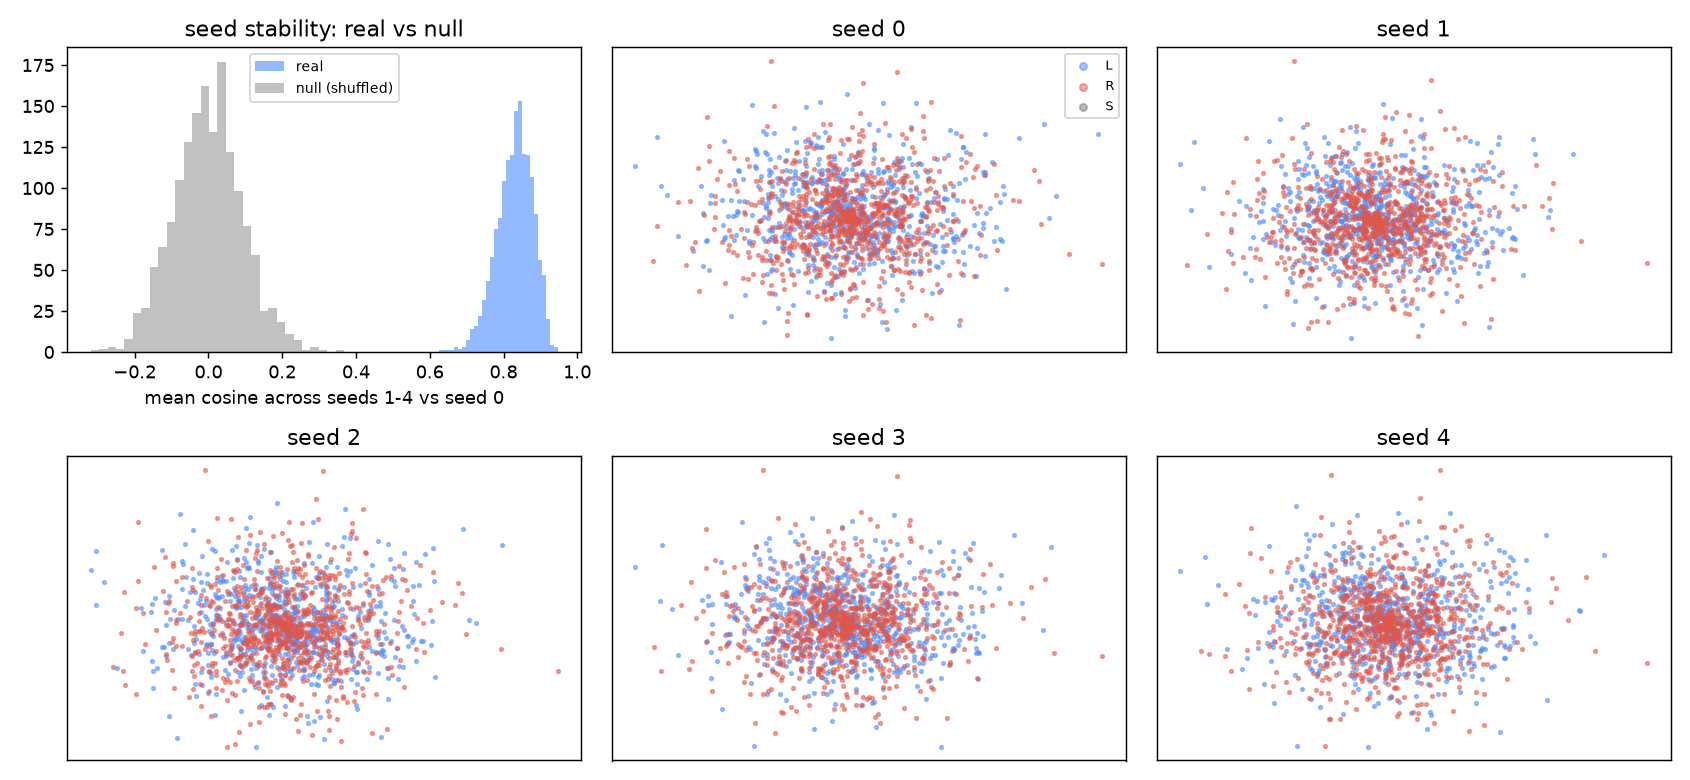

In [2]:
show(RESULTS / "fig_seed_stability.png")


In [3]:
with open(RESULTS / "seed_stability_summary.json") as f:
    seed_stability = json.load(f)

print(f"median cosine real: {seed_stability['median_cosine_real']:.4f}")
print(f"median cosine null: {seed_stability['median_cosine_null']:.4f}")
print(f"median diff 95pct ci: {seed_stability['diff_ci95']}")
SEED_STABLE = seed_stability["passes"]
print(f"verdict: {'agreement above null' if SEED_STABLE else 'FAIL, seed-specific'}")


median cosine real: 0.8345
median cosine null: -0.0015
median diff 95pct ci: [0.8295921941605379, 0.8410383861411712]
verdict: agreement above null


## Stand map

Two-dimensional projection of all 1,762 hitter rows, colored by batting stand, with the
five anchors labelled. PCA is the primary projection and t-SNE a second view, per the
spec's frozen projection choice.

**Expectation:** Stand separable above chance: out-of-fold logistic accuracy on the 2-D coordinates > 0.5, interval excluding 0.5. Prior: weaker than Alcorn 2018, since stand is also in the context vector.

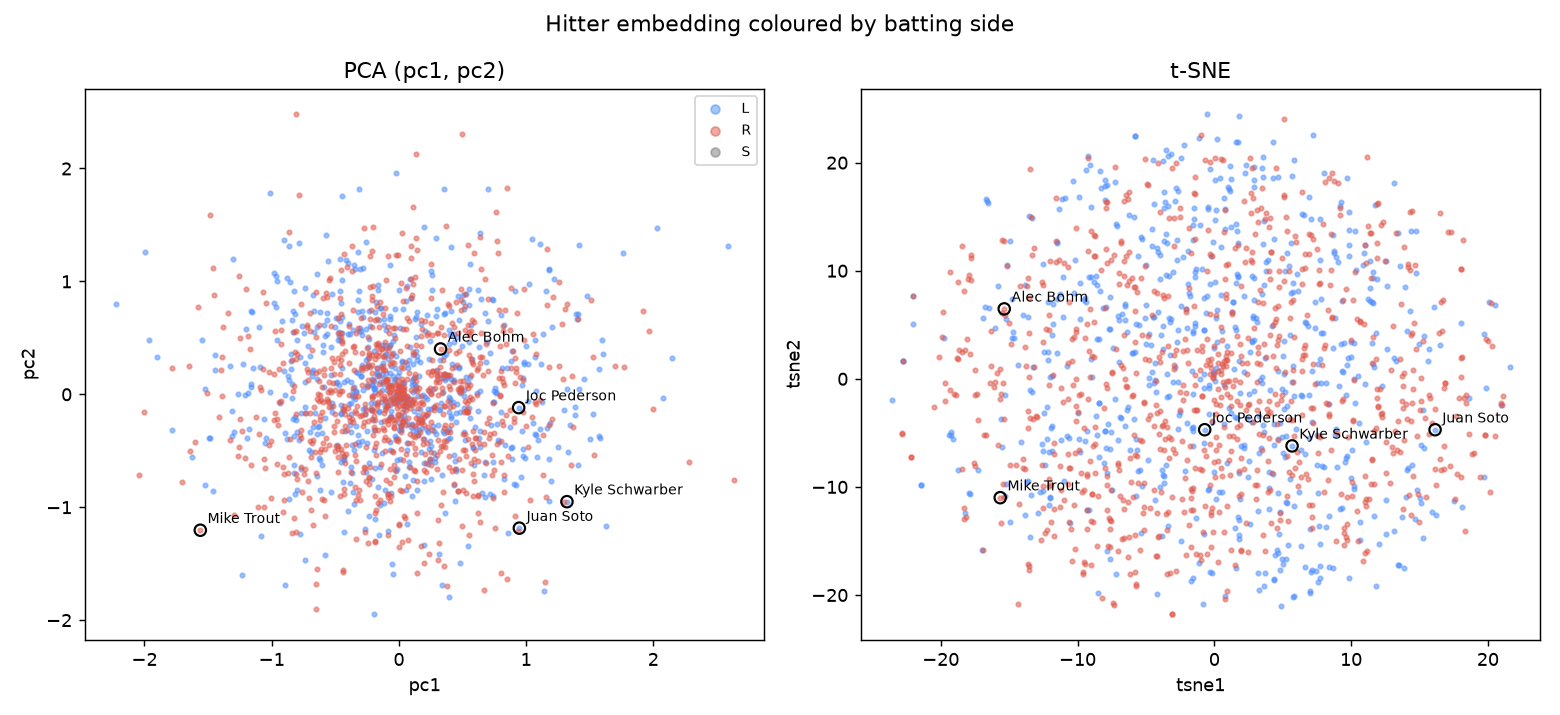

In [4]:
show(RESULTS / "fig_stand_map.png")


In [5]:
with open(RESULTS / "stand_separability.json") as f:
    stand_separability = json.load(f)

for method in ("pca", "tsne"):
    m = stand_separability[method]
    print(f"{method} accuracy: {m['accuracy']:.4f} ci: {m['accuracy_ci95']}")

both_exclude_half = stand_separability["pca"]["passes"] and stand_separability["tsne"]["passes"]
print(f"verdict: {'both CIs exclude 0.5' if both_exclude_half else 'FAIL'}"
      + (" (seed-specific)" if not SEED_STABLE else ""))


pca accuracy: 0.5518 ci: [0.5255754475703325, 0.5773657289002557]
tsne accuracy: 0.5659 ci: [0.540920716112532, 0.5914322250639387]
verdict: both CIs exclude 0.5


## Exposure map

Same 2-D map colored by log prior PA, alongside the embedding norm versus exposure curve.

**Expectation:** PC1 <-> log PA positive; norm rises with exposure (weight-decay shrinkage).

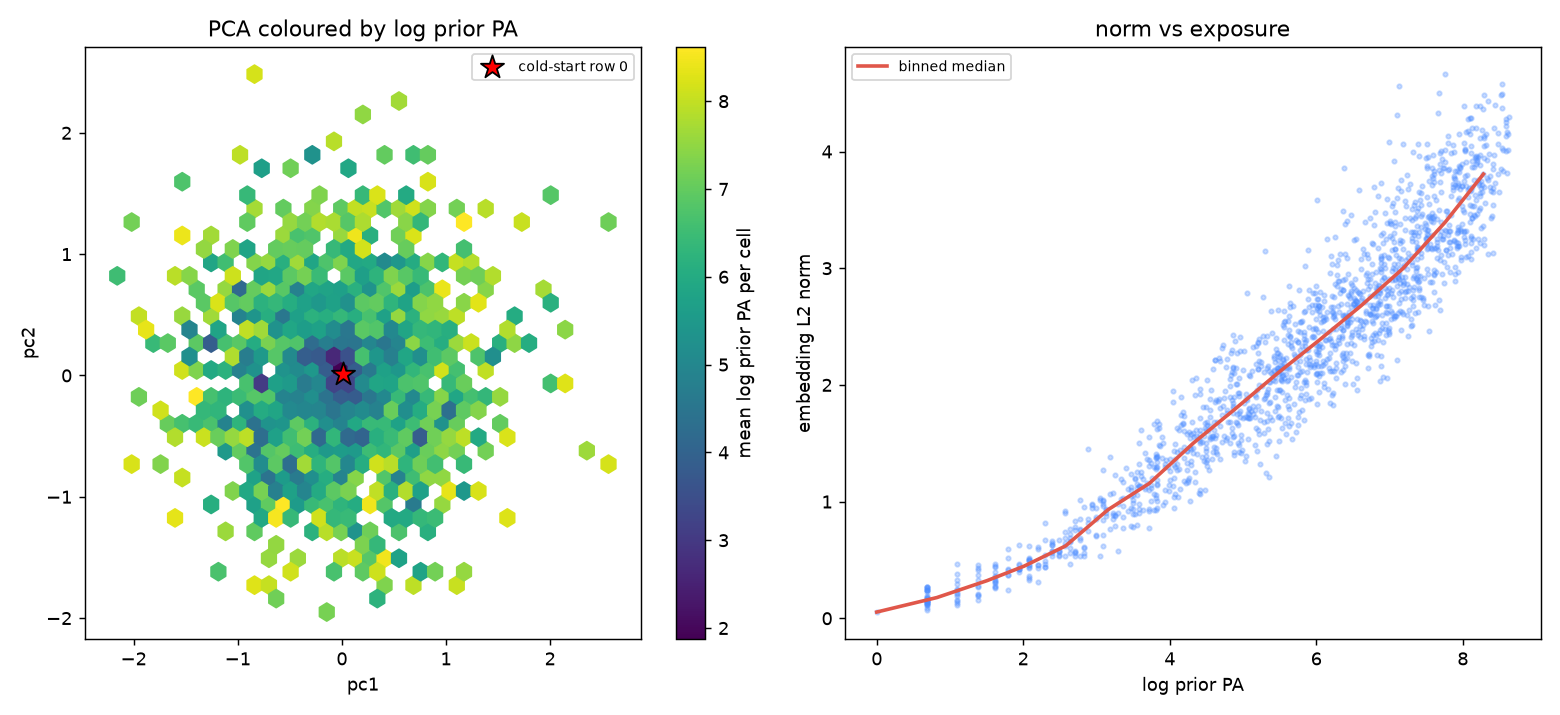

In [6]:
show(RESULTS / "fig_exposure_map.png")


In [7]:
with open(RESULTS / "exposure_loadings.json") as f:
    exposure_loadings = json.load(f)

print(f"pc1 abs r: {exposure_loadings['pc1_abs_r']:.4f} ci: {exposure_loadings['pc1_abs_r_ci95']}")
print(f"verdict pc1 vs log pa: {'pass' if exposure_loadings['pc1_passes'] else 'FAIL'}")

print(f"norm r: {exposure_loadings['norm_r']:.4f} ci: {exposure_loadings['norm_r_ci95']}")
print(f"verdict norm vs exposure: {'pass' if exposure_loadings['norm_passes'] else 'FAIL'}")


pc1 abs r: 0.0556 ci: [0.014768206715360152, 0.09931266430538964]
verdict pc1 vs log pa: pass
norm r: 0.9471 ci: [0.9422955024072511, 0.9516871423511036]
verdict norm vs exposure: pass


Norm rises with exposure on the canonical SGD-embedding build: slope +0.44 per log-PA unit, r ~ +0.93, CI excludes zero on the pre-registered side. Under the earlier AdamW build (`d10_baseline`) the sign was opposite (r ~ -0.71); the 2026-09-03 decision-log entry records the swap.

## Cold start row

Distance of the cold-start row (row 0, shared by 97 eval hitters with no training PA) to the exposure-weighted and unweighted centroid of the cloud.

**Expectation:** Descriptive: distance to the exposure-weighted centroid.

In [8]:
with open(RESULTS / "cold_start.json") as f:
    cold_start = json.load(f)

weighted = cold_start["weighted"]
print(f"row 0 distance (exposure weighted centroid): {weighted['row0_distance']:.4f}")
print(f"hitter distance mean: {weighted['hitter_dist_mean']:.4f} std: {weighted['hitter_dist_std']:.4f}")
print(f"z score: {weighted['z_score']:.4f}")
print("verdict: descriptive")


row 0 distance (exposure weighted centroid): 0.0512
hitter distance mean: 2.3126 std: 1.0390
z score: -2.1766
verdict: descriptive


## Dimension usage

Effective rank of the 32-dim embedding table, reported as a number (participation ratio and per-component explained variance), not a figure.


**Expectation:** Descriptive: effective rank < 32.


In [9]:
with open(RESULTS / "dimension_usage.json") as f:
    dimension_usage = json.load(f)

pca_explained_variance = pd.read_csv(RESULTS / "pca_explained_variance.csv")
display(pca_explained_variance.head(10))

print(f"effective rank: {dimension_usage['effective_rank']:.4f} of {dimension_usage['n_dims']} dims")
print(f"participation ratio: {dimension_usage['participation_ratio']:.4f}")
print("verdict: descriptive")


,component,explained_variance_ratio,cumulative_explained_variance
0,1,0.064221,0.064221
1,2,0.060153,0.124374
2,3,0.054033,0.178407
3,4,0.044690,0.223097
4,5,0.040693,0.263790
5,6,0.040137,0.303928
6,7,0.034228,0.338155
7,8,0.032345,0.370501
8,9,0.029373,0.399874
9,10,0.028444,0.428318


effective rank: 46.3040 of 64 dims
participation ratio: 35.8176
verdict: descriptive


## Head partial-correlation heatmap

A heatmap of partial Pearson r (partialled on log prior PA) between each factor head's marginal (swing, contact, split_inplay, ev, la, spray) and each observable stat, with a starred/bold cell where the 95% bootstrap CI excludes zero, plus the existing PCs-vs-marginals loadings heatmap.


**Expectation:** Partialled on log PA: contact marginal <-> observed contact rate positive; EV marginal <-> observed mean EV positive. Remaining cells descriptive.

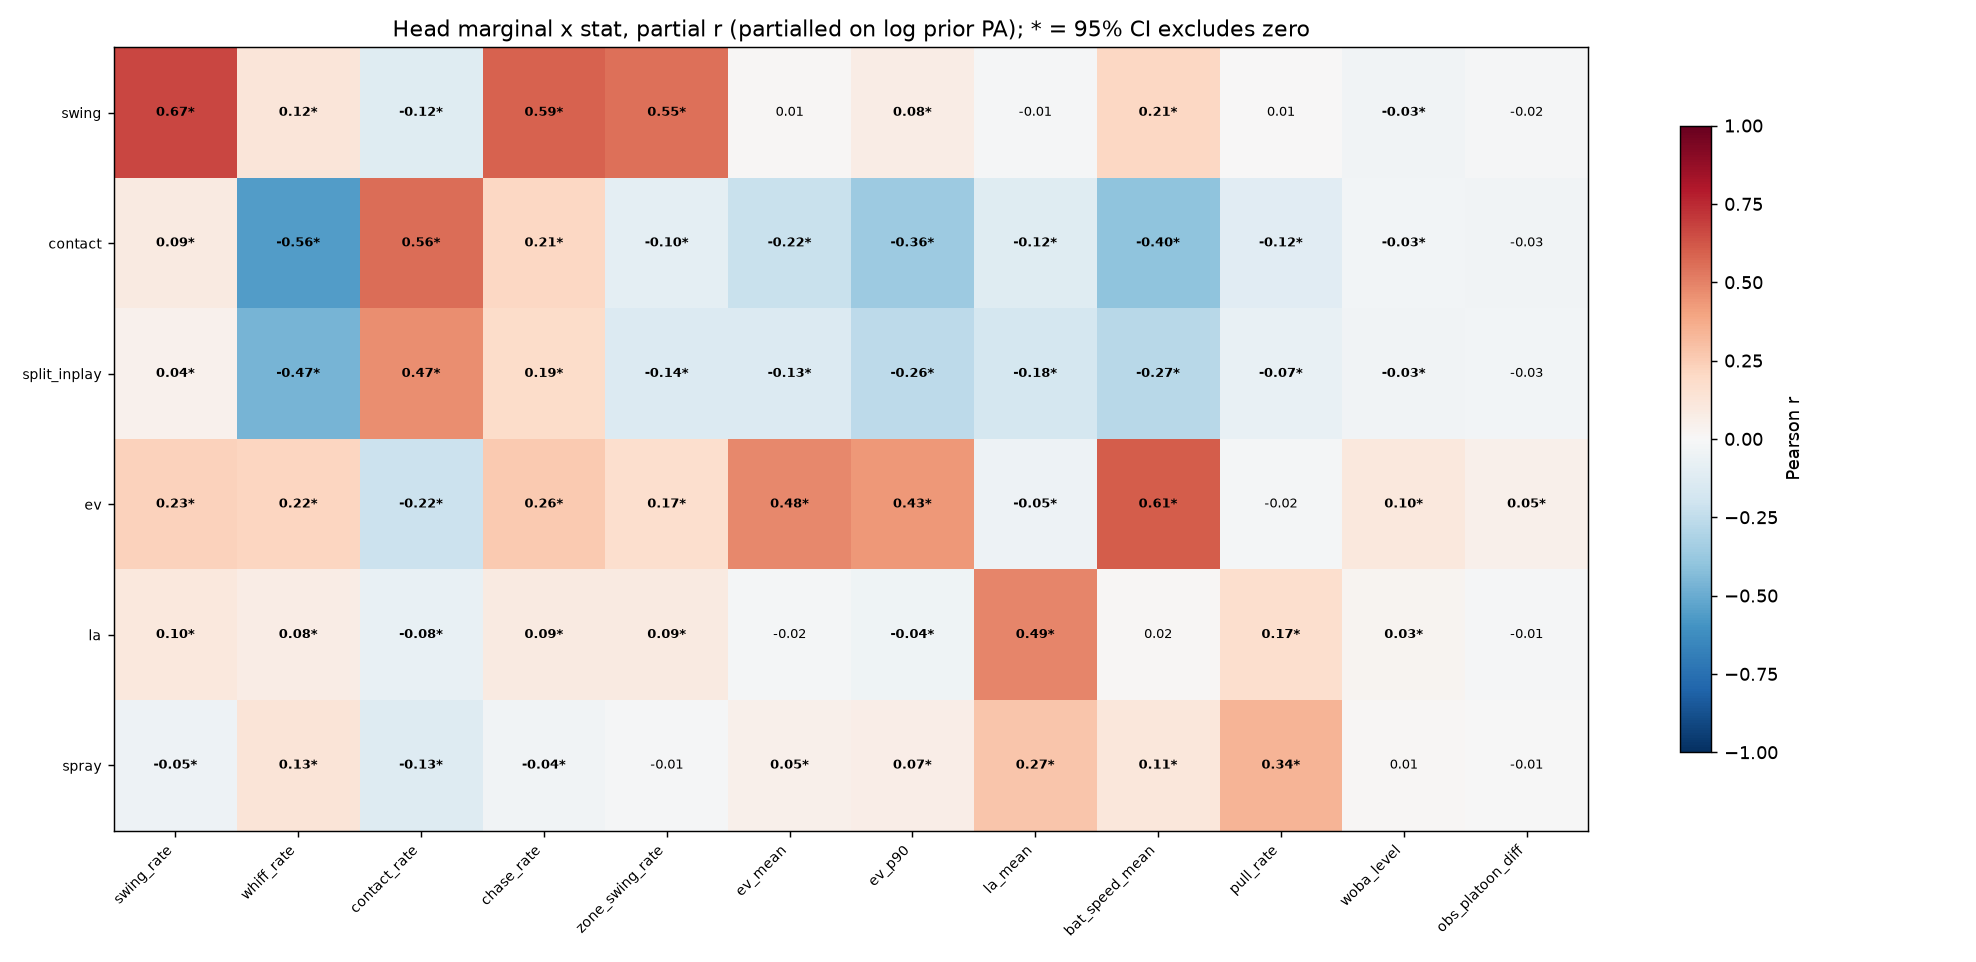

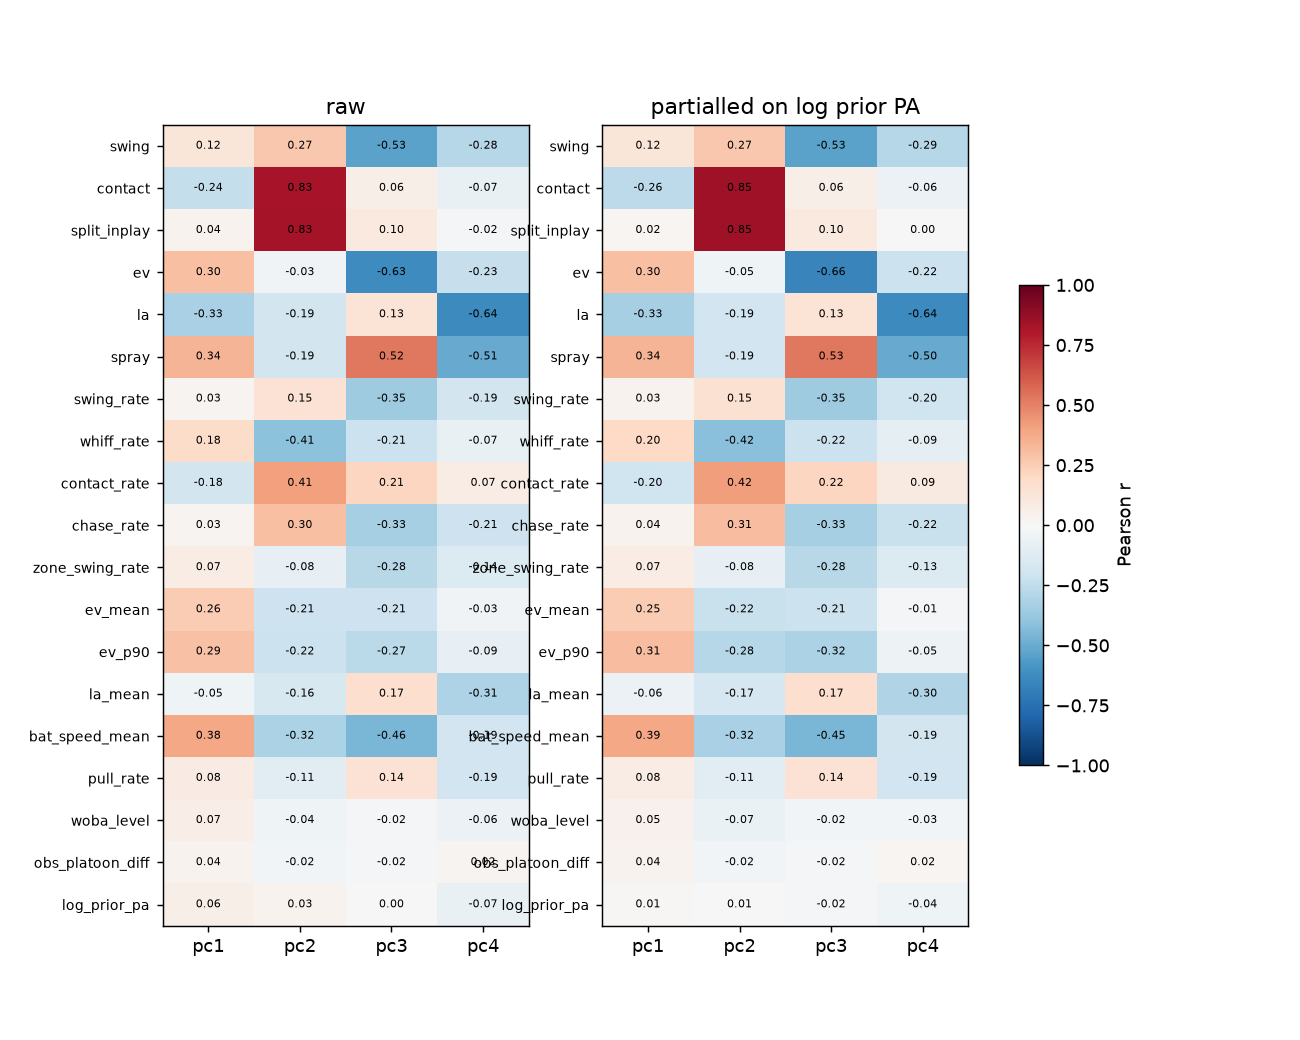

In [10]:
show(RESULTS / "fig_head_partial_heatmap.png")
show(RESULTS / "fig_loadings.png")


In [11]:
with open(RESULTS / "head_stat_loadings.json") as f:
    head_stat_loadings = json.load(f)

loadings = pd.read_csv(RESULTS / "loadings.csv")
display(loadings.head(10))

for key in ("contact_vs_contact_rate", "ev_vs_ev_mean"):
    m = head_stat_loadings[key]
    print(f"{key}: r_raw={m['r_raw']:.4f} r_partial={m['r_partial']:.4f} "
          f"ci=[{m['ci_low']:.4f}, {m['ci_high']:.4f}]")
    print(f"verdict {key}: {'pass' if m['verdict'] else 'FAIL'}")

print("remaining loadings cells: descriptive")


,pc,variable,r_raw,r_partial,n
0,pc1,swing,0.117654,0.117595,1564
1,pc1,contact,-0.235047,-0.259178,1564
2,pc1,split_inplay,0.035593,0.021695,1564
3,pc1,ev,0.304023,0.302267,1564
4,pc1,la,-0.325600,-0.329983,1564
5,pc1,spray,0.342346,0.339190,1564
6,pc1,swing_rate,0.026463,0.034200,1564
7,pc1,whiff_rate,0.180324,0.197514,1563
8,pc1,contact_rate,-0.180324,-0.197514,1563
9,pc1,chase_rate,0.027895,0.035259,1559


contact_vs_contact_rate: r_raw=0.5842 r_partial=0.5596 ci=[0.5051, 0.6136]
verdict contact_vs_contact_rate: pass
ev_vs_ev_mean: r_raw=0.5235 r_partial=0.4790 ci=[0.4274, 0.5371]
verdict ev_vs_ev_mean: pass
remaining loadings cells: descriptive


## Level query map

Map colored by the model's level query (mean of score_L, score_R) and by training wOBA, broken out by exposure stratum.

**Expectation:** Level query <-> wOBA positive in the high stratum.

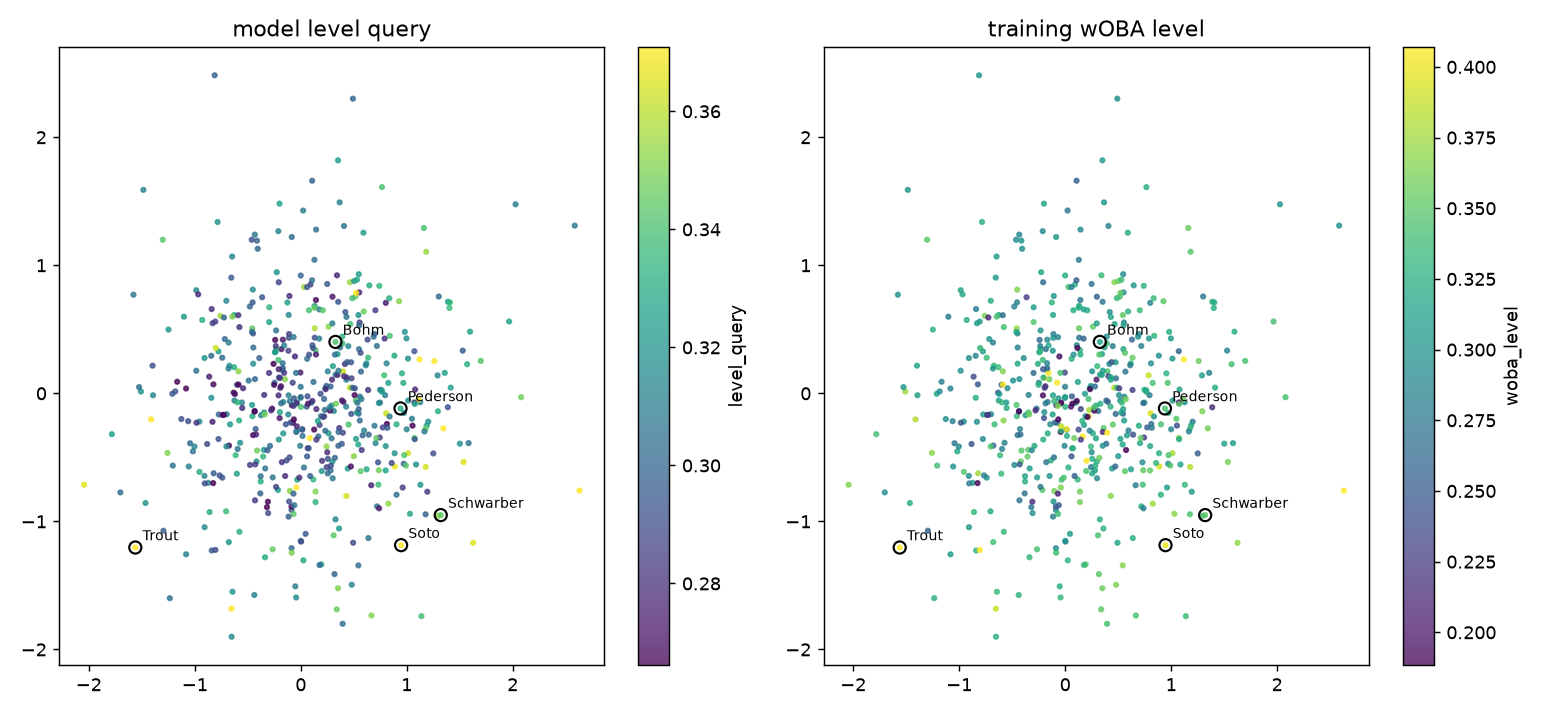

In [12]:
show(RESULTS / "fig_level_map.png")


In [13]:
with open(RESULTS / "level_query.json") as f:
    level_query = json.load(f)

for stratum in ("low", "medium", "high"):
    m = level_query[stratum]
    print(f"{stratum} stratum n={m['n']} r_raw={m['r_raw']:.4f} r_partial={m['r_partial']:.4f} "
          f"ci=[{m['ci_low']:.4f}, {m['ci_high']:.4f}]")

high = level_query["high"]
print(f"verdict (high stratum only): {'pass' if high['verdict'] else 'FAIL'}")


low stratum n=174 r_raw=0.2506 r_partial=0.2085 ci=[0.0907, 0.3330]
medium stratum n=190 r_raw=0.6029 r_partial=0.5529 ci=[0.4531, 0.6456]
high stratum n=177 r_raw=0.8521 r_partial=0.8281 ci=[0.7648, 0.8750]
verdict (high stratum only): pass


## Platoon direction

(a) Gradient of the L-R query gap with respect to the embedding, compared against the ridge probe's weight vector (the linear-decodability probe) by cosine similarity. (b) Projection on the gradient direction versus the observed platoon differential, per stratum and pooled. (c) Spread of that projection by stratum.

**Expectation:** (a) cosine > 0. (b) positive in the high stratum; the probe's pooled Pearson 0.195 [0.124, 0.267] is the prior. (c) spread low < high, section 1.4's failure mode, seen directly. Three sub-verdicts below: (a) cosine > 0, (b) high-stratum partial r > 0, (c) spread low < high.

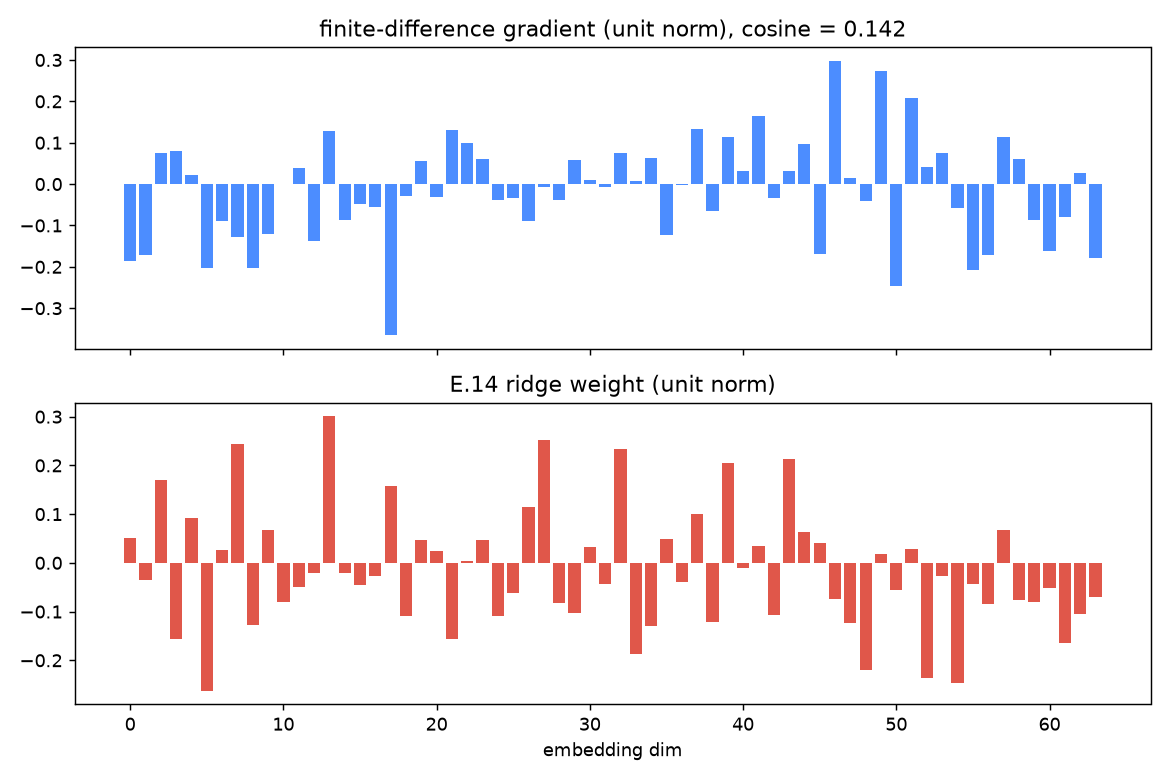

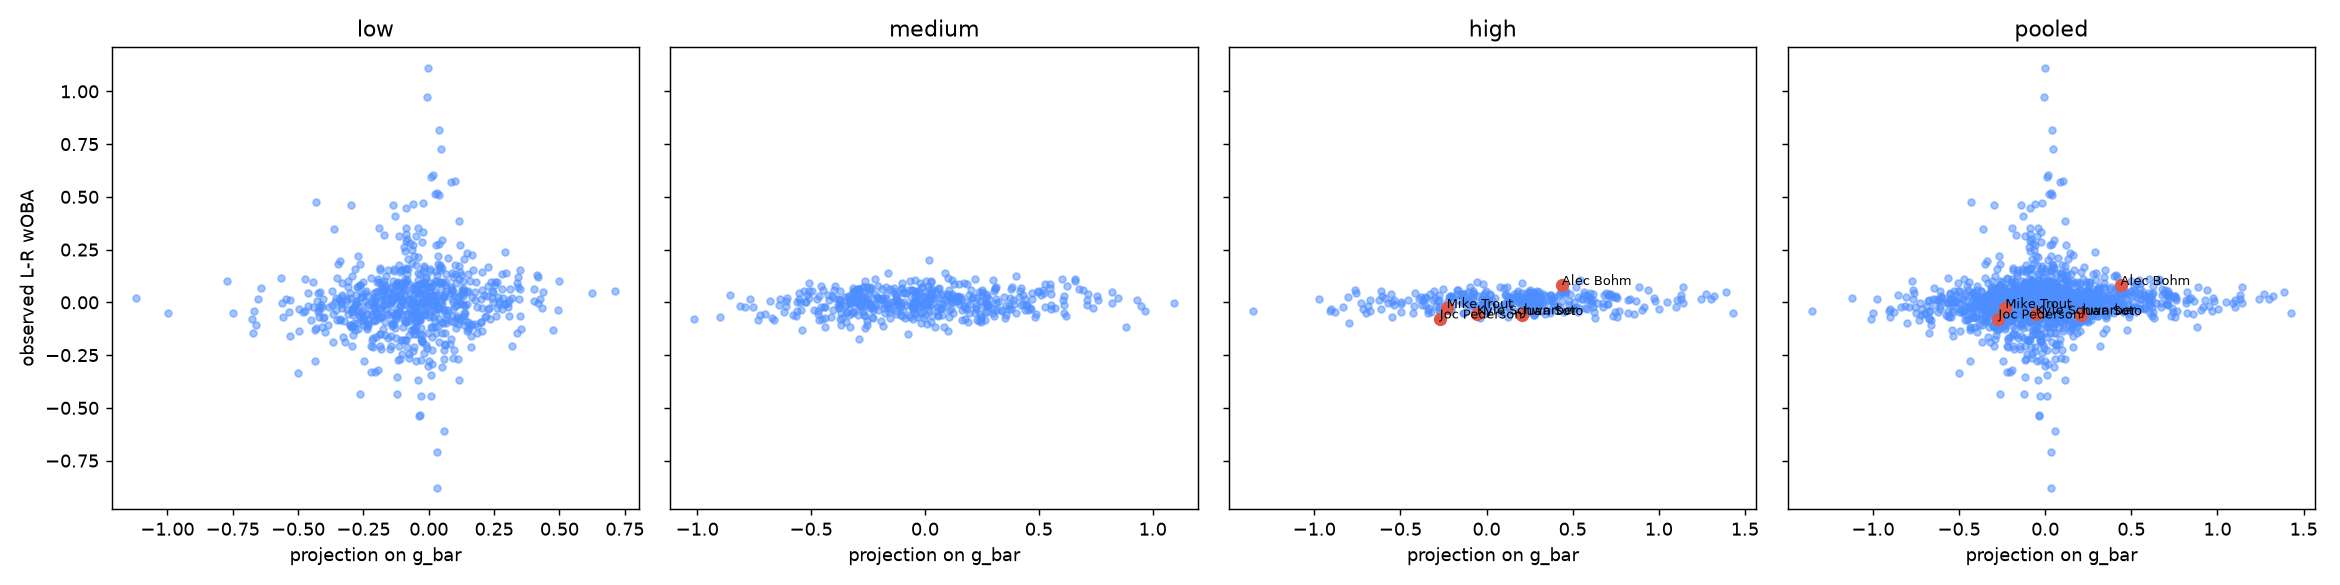

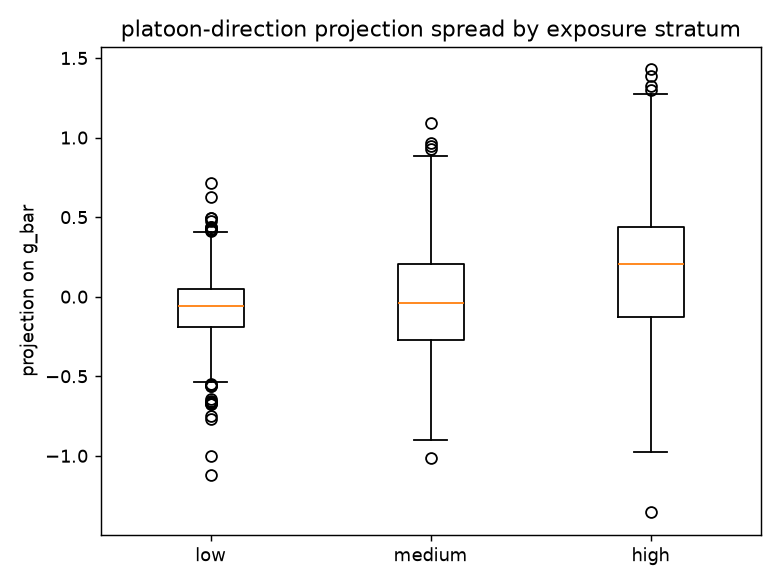

In [14]:
show(RESULTS / "fig_platoon_direction.png")
show(RESULTS / "fig_platoon_projection.png")
show(RESULTS / "fig_platoon_spread.png")


In [15]:
with open(RESULTS / "platoon_projection.json") as f:
    platoon_projection = json.load(f)

direction = platoon_projection["direction"]
print(f"(a) cosine: {direction['cosine']:.4f} ci: {direction['cosine_ci']}")
print(f"verdict (a) cosine > 0: {'pass' if direction['verdict'] else 'FAIL'}")

high_corr = platoon_projection["correlations"]["high"]
print(f"(b) high stratum partial r: {high_corr['partial']:.4f} ci: {high_corr['partial_ci']}")
print(f"verdict (b) high stratum partial r > 0: "
      f"{'pass' if platoon_projection['verdict_high_stratum'] else 'FAIL'}")

spread = platoon_projection["spread"]
for stratum, s in spread["sd_by_stratum"].items():
    print(f"(c) {stratum} stratum spread sd: {s['point']:.4f} ci: {s['ci']}")
print(f"(c) high minus low diff ci: {spread['diff_high_minus_low_ci']}")
print(f"verdict (c) spread low < high: {'pass' if spread['verdict'] else 'FAIL'}")


(a) cosine: 0.1417 ci: [0.08108033130743111, 0.20103035918371237]
verdict (a) cosine > 0: pass
(b) high stratum partial r: 0.1331 ci: [0.014466492099439399, 0.24361801600546926]
verdict (b) high stratum partial r > 0: pass
(c) high stratum spread sd: 0.4595 ci: [0.42056248065572793, 0.49110678436715444]
(c) low stratum spread sd: 0.2117 ci: [0.1973161714449296, 0.2271398054415313]
(c) medium stratum spread sd: 0.3494 ci: [0.3258834485572323, 0.3720604765861519]
(c) high minus low diff ci: [0.20754379128185954, 0.2844473605102358]
verdict (c) spread low < high: pass


## Nearest neighbours

Nearest neighbours by cosine similarity in the embedding for the five anchors, next to nearest neighbours by the observable-stat vector. The platoon column is the stand-oriented observed platoon differential; positive means better against the opposite hand.

**Expectation:** Descriptive, named. Pederson, Schwarber, and Bohm neighbours share stand and platoon sign; Trout and Soto neighbours are high-wOBA.

In [16]:
show(RESULTS / "fig_neighbours.png")


NOT GENERATED ON THIS BUILD: fig_neighbours.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


In [17]:
if not missing("neighbours.csv"):
    neighbours = pd.read_csv(RESULTS / "neighbours.csv")
    display_cols = ["rank", "name", "stand", "stratum", "woba_level", "obs_platoon_diff"]

    for anchor_name in neighbours["anchor_name"].unique():
        print(f"anchor: {anchor_name}")
        anchor_rows = neighbours[neighbours["anchor_name"] == anchor_name]
        for method in ("embedding", "stats"):
            print(f"  by {method}:")
            display(anchor_rows[anchor_rows["method"] == method][display_cols].head(5))

    print("verdict: descriptive")


NOT GENERATED ON THIS BUILD: neighbours.csv
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


Pooled and high-stratum views are both reported; V is descriptive and per-stratum is the pre-registered design.


In [18]:
show(RESULTS / "fig_neighbours_high.png")


NOT GENERATED ON THIS BUILD: fig_neighbours_high.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


## Conditional surfaces

Expected wOBA surfaces for the five anchors through the existing scorer, versus LHP and versus RHP, against the league. Head marginals p_swing, p_contact, and in-play quality q are shown separately rather than as a composite.

**Expectation:** Descriptive. Pederson and Schwarber lower vs LHP than vs RHP; Bohm the reverse; Trout and Soto near-flat. Static preview of the planned query-dashboard build (non-handedness conditional queries), same scorer path.

In [19]:
show(RESULTS / "fig_surfaces_type_count.png")
show(RESULTS / "fig_surfaces_location.png")


NOT GENERATED ON THIS BUILD: fig_surfaces_type_count.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: fig_surfaces_location.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


In [20]:
if not missing("surfaces_summary.csv"):
    surfaces_summary = pd.read_csv(RESULTS / "surfaces_summary.csv")
    quality = surfaces_summary[surfaces_summary["quantity"] == "q"]
    quality_wide = quality.pivot(index="anchor_name", columns="p_throws", values="delta")
    quality_wide["q_delta_l_minus_r"] = quality_wide["L"] - quality_wide["R"]
    display(quality_wide.rename(columns={"L": "q_delta_vs_lhp", "R": "q_delta_vs_rhp"}))

    print("verdict: descriptive")


NOT GENERATED ON THIS BUILD: surfaces_summary.csv
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


## Disagreement

Model rank versus `eb_bivariate` rank on the platoon differential, per stratum and pooled, with a top-N table of the largest rank gaps naming exposure and both ranks. This is on whom the model and the empirical-Bayes estimate disagree, not who is right.

**Expectation:** Descriptive. On whom, not who is right.

In [21]:
show(RESULTS / "fig_disagreement.png")


NOT GENERATED ON THIS BUILD: fig_disagreement.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


In [22]:
if not missing("disagreement_summary.json", "disagreement_top.csv"):
    with open(RESULTS / "disagreement_summary.json") as f:
        disagreement_summary = json.load(f)

    for stratum in ("low", "medium", "high", "pooled"):
        m = disagreement_summary[stratum]
        print(f"{stratum}: n={m['n_hitters']} spearman={m['spearman']:.4f} "
              f"rank gap sd={m['rank_gap_sd']:.4f}")

    disagreement_top = pd.read_csv(RESULTS / "disagreement_top.csv")
    display(disagreement_top.head(10))

    print("verdict: descriptive")


NOT GENERATED ON THIS BUILD: disagreement_summary.json
NOT GENERATED ON THIS BUILD: disagreement_top.csv
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


## Attribute axes

Four scatter figures read from `EMBEDDING_STRUCTURE`, which defaults to
`results/v_chain_clean/embedding_structure/`, not from `RESULTS`. Each one
places every qualified hitter on two supervised directions through the frozen embedding.

The protocol is the same for every axis. The embedding is trained on pitches and outcomes
only and never sees the plotted quantity. Hitter vectors are frozen, then an LDA is fit
post hoc to separate terciles of one measured metric. The reported number is the held out
accuracy of that LDA under 5 fold cross validation, seed 7. Chance for a tercile is 0.333.
The in sample picture separates by construction and carries no claim.

Two readings apply to every panel.

1. The third panel colours 12x12 cells by mean `woba_level`, a quantity on neither axis, so
   the gradient is not true by construction. Cells holding fewer than five hitters are grey.
2. Both axes are directions in one low dimensional learned space, so they share its dominant
   variance. Every pairing's correlation in LDA space exceeds the correlation the hitters
   themselves have. The table below reports both, and the visible tilt should be read against
   the hitter level number, not the projected one.


In [23]:
EMB = EMBEDDING_STRUCTURE

with open(EMB / "embedding_alt_views.json") as f:
    alt_views = json.load(f)

axes_table = pd.DataFrame([
    {
        "pairing": pid,
        "x metric": s["x"]["metric"],
        "x held-out CV": round(s["x"]["lda_cv_accuracy_mean"], 3),
        "y metric": s["y"]["metric"],
        "y held-out CV": round(s["y"]["lda_cv_accuracy_mean"], 3),
        "hitters": s["n_hitters_plotted"],
        "r (LDA space)": round(s["axis_correlation"]["lda_projected"], 3),
        "r (hitter level)": round(s["axis_correlation"]["raw_metric"], 3),
    }
    for pid, s in alt_views["pairings"].items()
])
axes_table


,pairing,x metric,x held-out CV,y metric,y held-out CV,hitters,r (LDA space),r (hitter level)
0,power_contact,ev_p90,0.791,contact_rate,0.754,1493,-0.438,-0.224
1,discipline,zone_swing_rate,0.746,chase_rate,0.734,1493,0.531,0.375
2,spin_vs_fastball,whiff_rate_brk,0.698,whiff_rate_fb,0.753,1335,0.640,0.532
3,spin_vs_fastball_damage,ev_p90_brk,0.743,ev_p90_fb,0.805,1203,0.938,0.831


### Power against contact

`ev_p90` against `contact_rate`. Both are marginals of heads the model is trained on
(`head_ev`, `head_contact`), so this pairing asks whether the space sorts the two best
measured hitter attributes, not whether it does something harder.


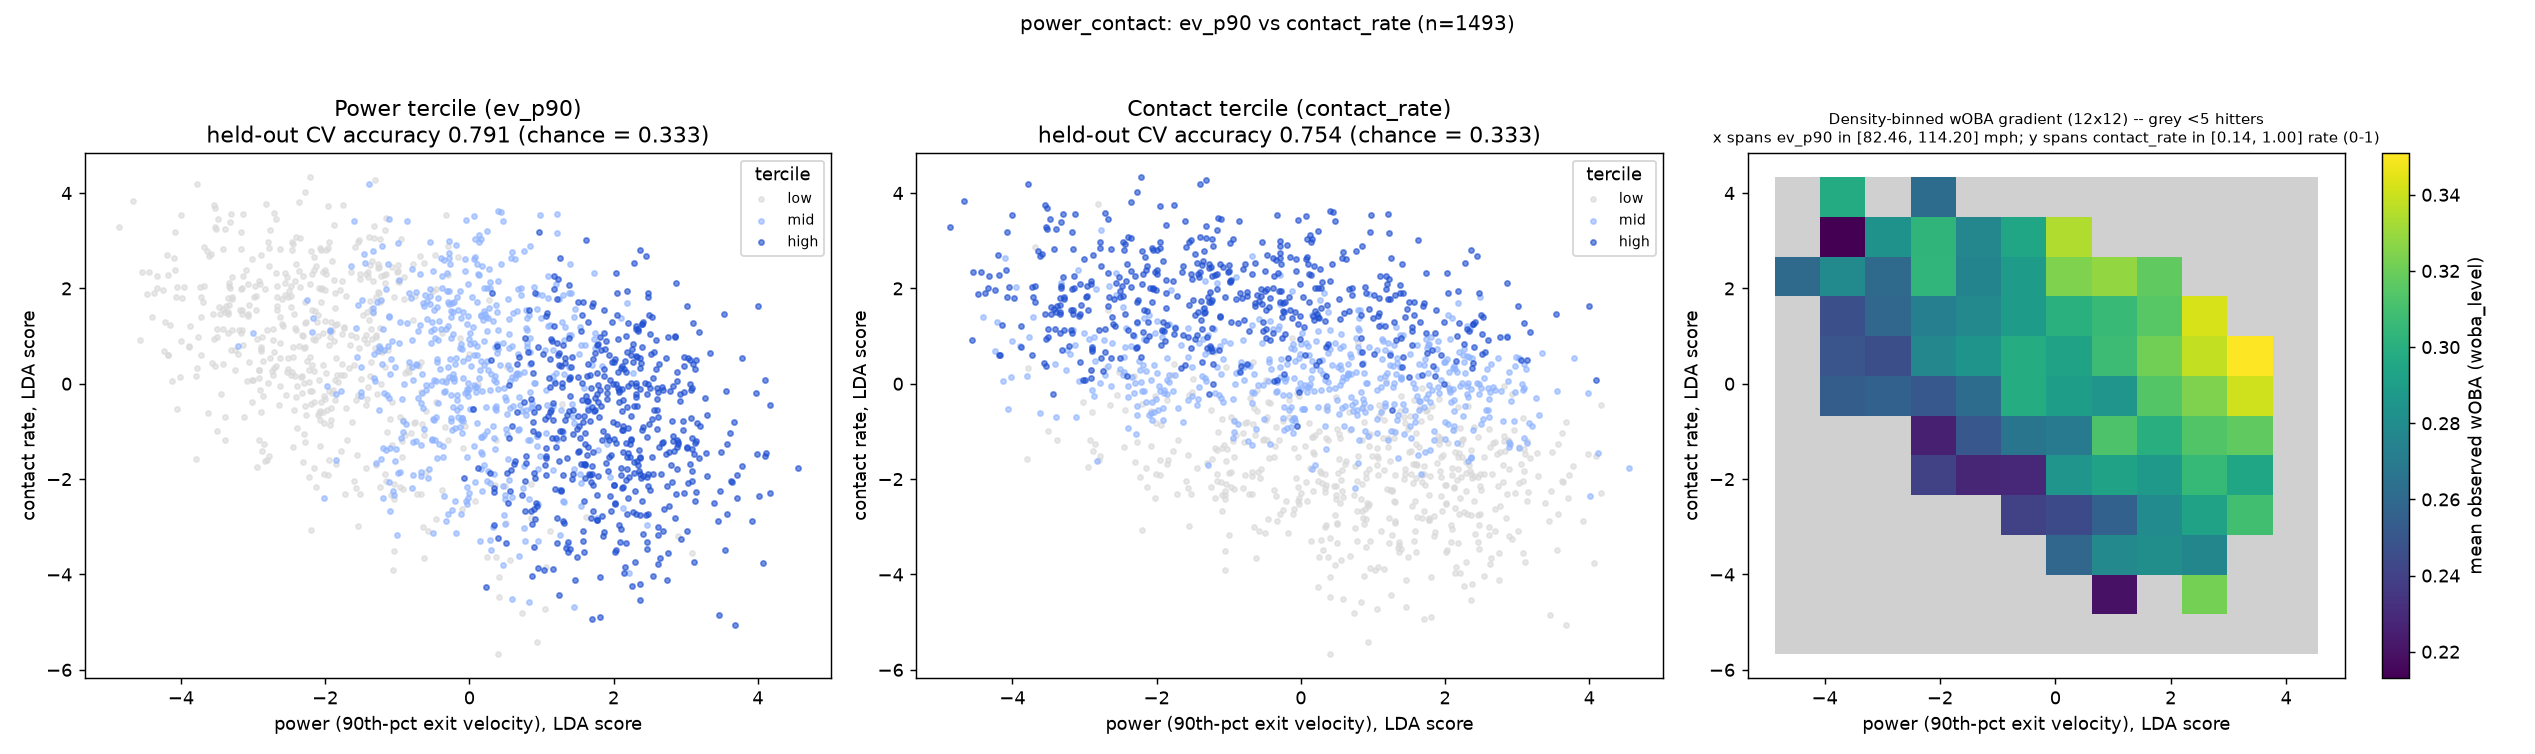

In [24]:
show(EMB / "figures" / "fig_axes_power_contact.png")

### Discipline

In zone swing rate against chase rate. The identity line matters here. `selectivity` is
zone swing minus chase, so distance from the diagonal is selectivity and position along it
is overall swing rate. Plotting the two raw rates does not lose the contrast, it rotates it.


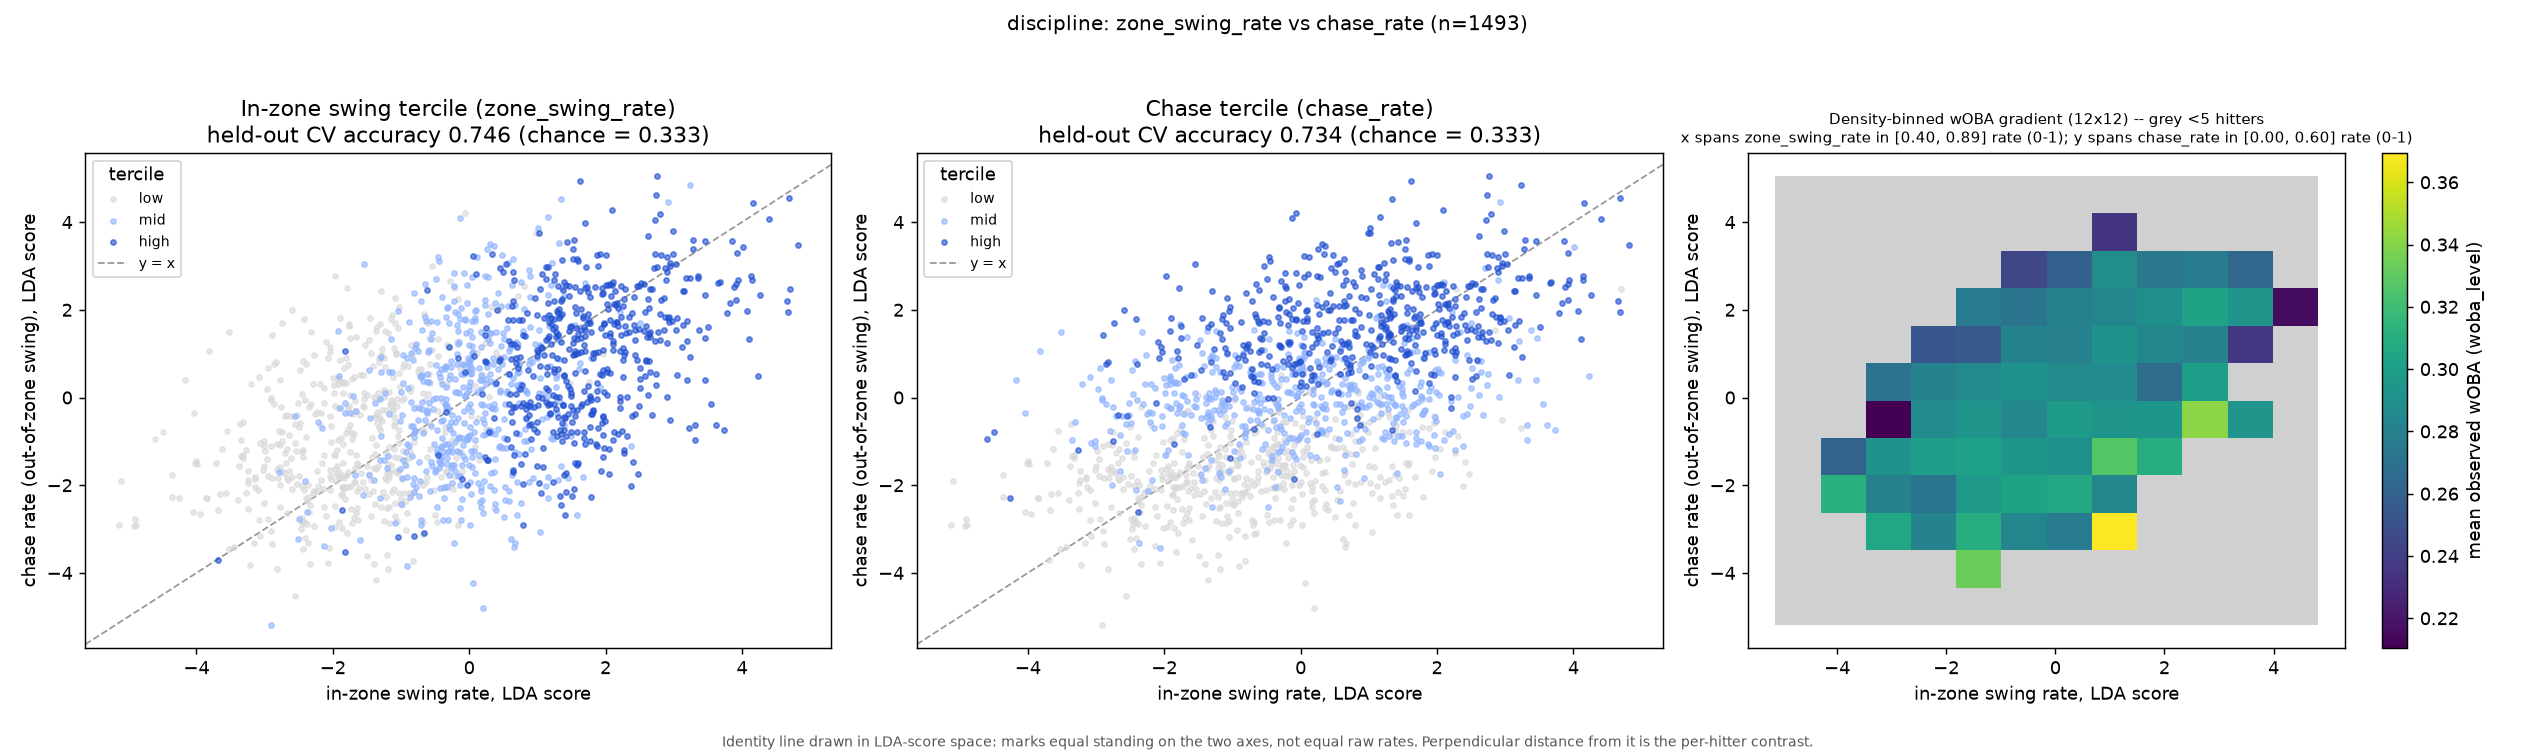

In [25]:
show(EMB / "figures" / "fig_axes_discipline.png")

### Breaking ball whiff against fastball whiff

Same identity line reading: the diagonal is overall whiff rate and perpendicular distance is
`whiff_brk_minus_fb`. The raw rates score higher than their difference (0.633) because they
carry the shared whiff level that the difference strips out.


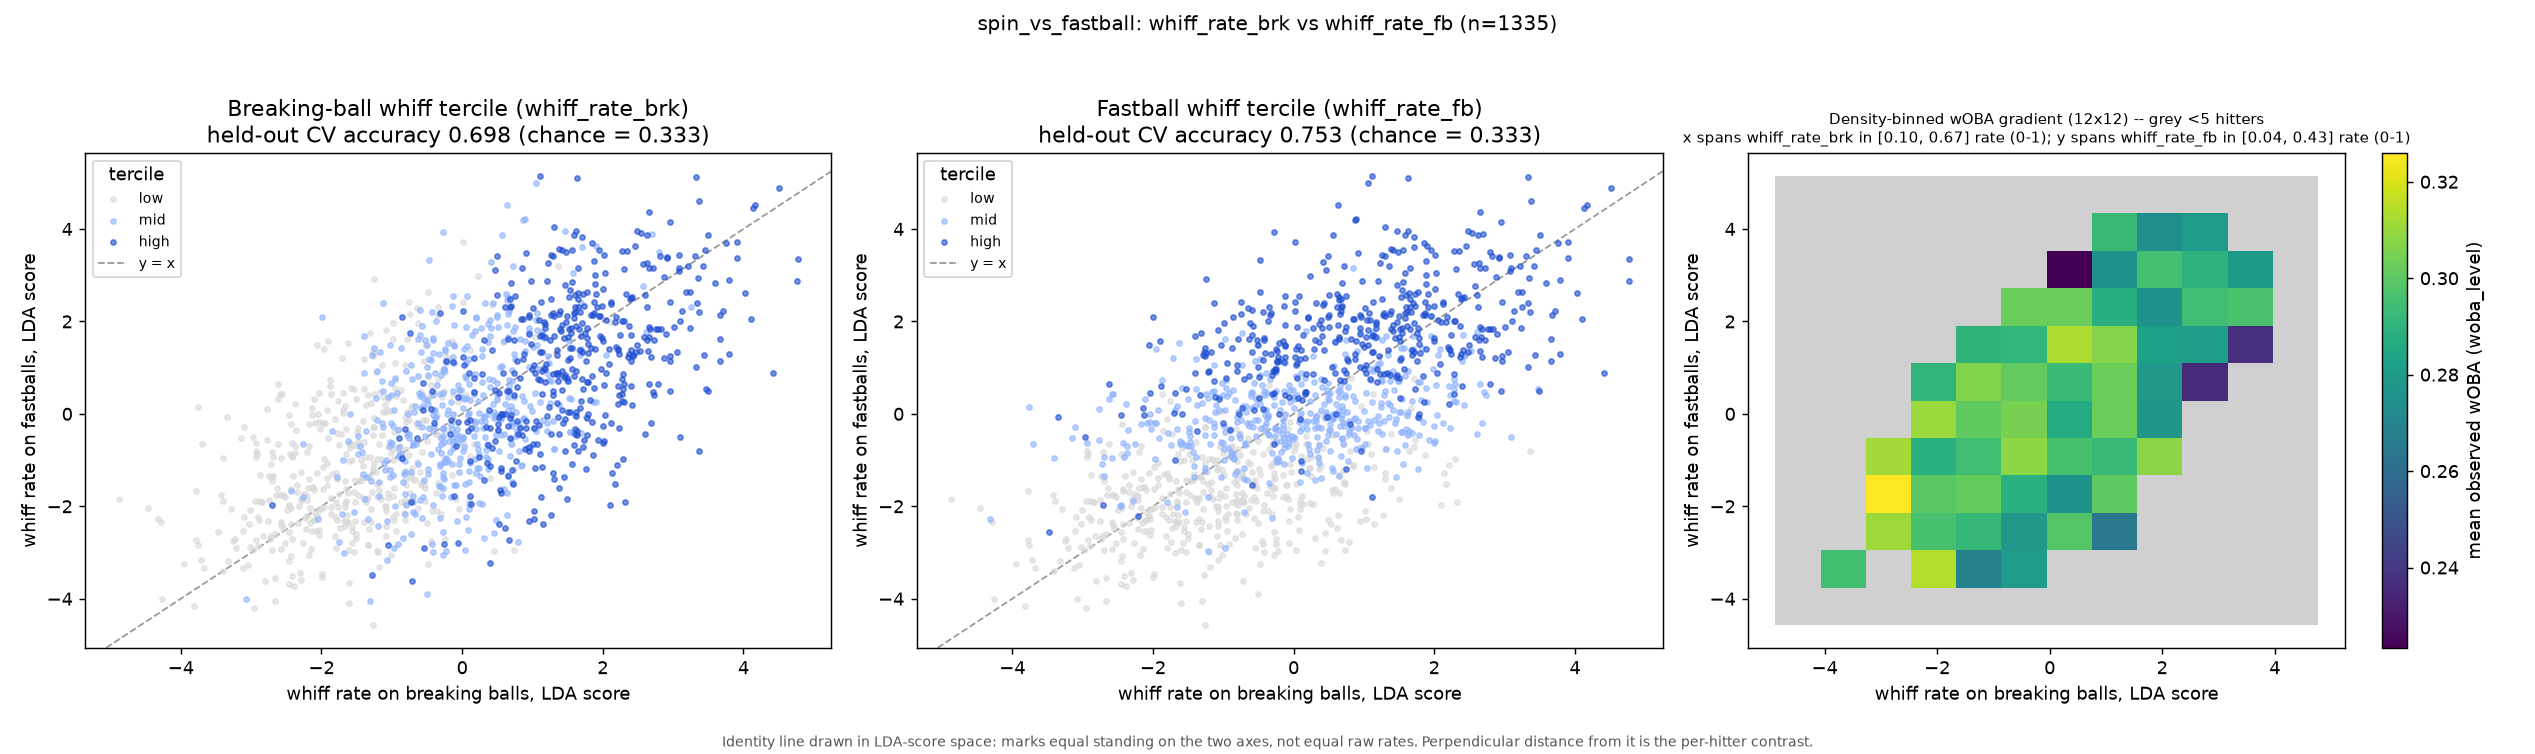

In [26]:
show(EMB / "figures" / "fig_axes_spin_vs_fastball.png")

### Breaking ball power against fastball power

Reported as a null. The two axes correlate 0.967 in LDA space, so breaking ball power and
fastball power are one direction in this embedding, not two. It is the contrast to the whiff
figure above: the space separates who misses which pitch family, and does not separate who
damages which.


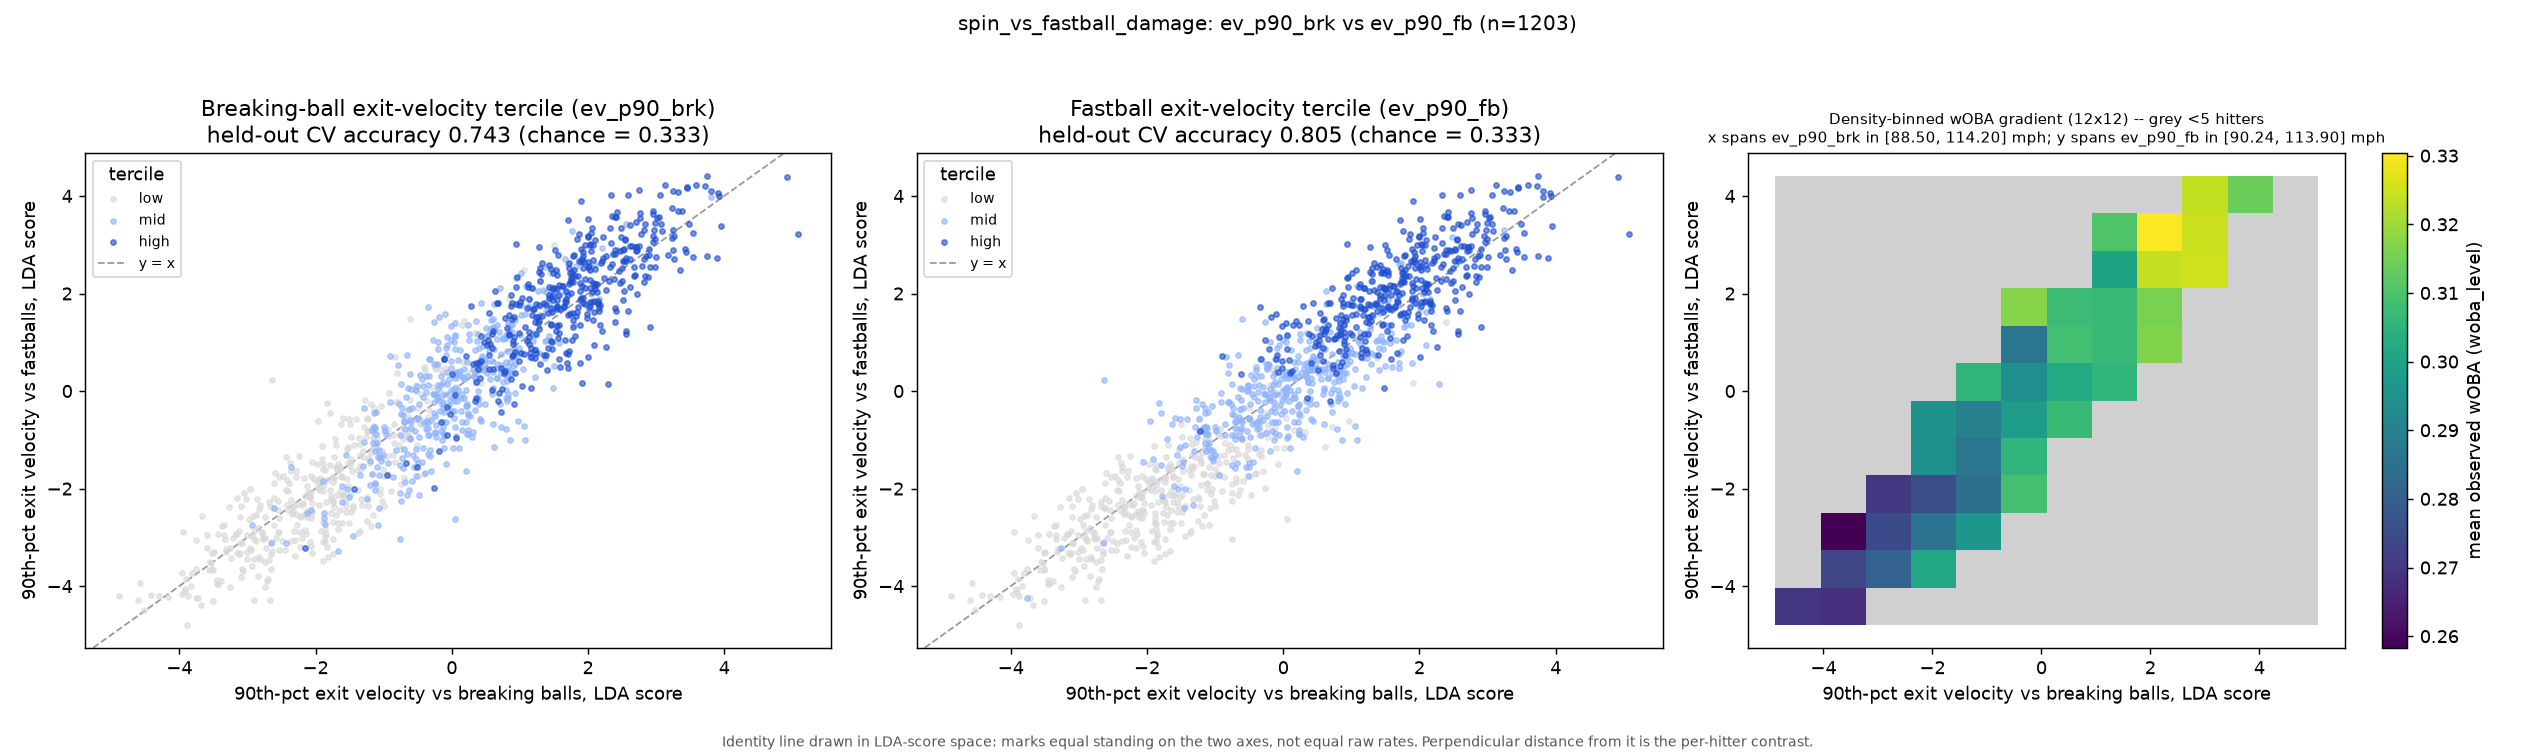

In [27]:
show(EMB / "figures" / "fig_axes_spin_vs_fastball_damage.png")

## Pitcher-type matchups (descriptive)

What the model predicts about which hitters do better or worse against a pitcher type, beyond their overall level.
Matchup effect = projected wOBA minus the hitter's own average vs RHP minus the pitcher's average over hitters.
2024 exploration build, RHP only. **Not validated**: the one-season reliability of these contrasts is about 0
(`results/pitcher_type_query/ceiling.csv`), so these are hypotheses for the sealed 2025 pass, not results.

Interactive version (leaderboards, hitter profiles, pitcher-vs-hitters): `explorer/`, published at
https://nseluga.github.io/Hitter-Embedding/. Figures come from `src/analysis/matchup_figures.py`.

### Two axes at once (all regulars)

x and y = the matchup contrasts on two pitcher axes (top vs bottom 20% on each). Each quadrant names the pitcher combination the model thinks suits him best, for example fastballs up plus breaking balls buried. Location is by pitch class against each batter's own zone: FB up = share of fastballs in the top third of the zone or above; brk below zone = share of breaking balls under the zone. The first figure is the north-south pair. Color = his own projected wOBA vs RHP.

In [28]:
PTQ = Path(os.environ.get("PTQ_RESULTS", "results/pitcher_type_query")) / "figures"
for x, y in (("location", "brk_location"), ("velo", "mix"), ("velo", "location")):
    show(PTQ / f"pair_{x}_{y}.png")

NOT GENERATED ON THIS BUILD: pair_location_brk_location.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: pair_velo_mix.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: pair_velo_location.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


### One hitter at a time (the dashboard's Hitter profile tab)

Color = matchup effect vs pitchers near that spot, fixed ±20 scale, red = better than his own RHP average. Gray = too few pitchers nearby. Dots = pitchers.

In [29]:
for x, y in (("fb_up", "brk_down"), ("fb_velo", "fb_up"), ("fb_velo", "brk_share")):
    show(PTQ / f"profile_{x}_{y}.png")

NOT GENERATED ON THIS BUILD: profile_fb_up_brk_down.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: profile_fb_velo_fb_up.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: profile_fb_velo_brk_share.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20


### One hitter map per pitcher axis

x = matchup effect against the top 20% minus the bottom 20% of RHP on that axis; y = the hitter's own projected wOBA vs RHP; color = batter hand.

In [30]:
for k in ("velo", "mix", "location", "brk_location"):
    show(PTQ / f"map_{k}.png")

NOT GENERATED ON THIS BUILD: map_velo.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: map_mix.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: map_location.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
NOT GENERATED ON THIS BUILD: map_brk_location.png
  its module was not re-run on the clean arm; see docs/decision-log.md 2026-09-20
